In [1]:
import os,sys
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import astropy
import h5py
sys.path.append('../../code/misc')
#import webplotdigitizer as wpd
from scipy.special import erf

%matplotlib inline
%load_ext autoreload
%autoreload 2
 
from scipy.stats import chi2 as chi2_scipy
from scipy.optimize import dual_annealing
from scipy.optimize import minimize

import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib import rcParams

from scipy.special import factorial

from astropy.coordinates import SkyCoord
from astropy import units as u

In [2]:
def loadFile(fileString):
    in_file = str(fileString + '/outputFile.h5')
    with h5py.File(in_file, 'r') as h5f:
        # Read each dataset back into memory
        counts = h5f['counts'][:]
        det_res = h5f['det_res'][:]
        exp = h5f['exp'][()]
        cin_min = h5f['cin_min'][:]
        cin_max = h5f['cin_max'][:]
        cout_min = h5f['cout_min'][:]
        cout_max = h5f['cout_max'][:]
        flux = h5f['flux'][:]
        effA = h5f['effA'][:]

    #We store our dec and ra separately, and unpack them here
    coordsFile = (fileString + '/declensionInfo.txt')
    with open(coordsFile, 'r') as textFile:
        lineIndex = 0
        for line in textFile:
            if lineIndex == 0:
                raDegrees = float(line) 
                lineIndex += 1
                
            elif lineIndex == 1:
                decDegrees = float(line)
                lineIndex += 1
                
            else:
                break

        #Now we convert ra and dec into their values in galactic coordinates
        celestialCoords = SkyCoord(ra=raDegrees * u.degree, dec=decDegrees * u.degree, frame="icrs")
        galacticCoords = celestialCoords.galactic
        lVal = galacticCoords.l.degree
        bVal = galacticCoords.b.degree
    
    E_mean = np.mean([cout_min, cout_max], axis = 0)
    dE = cout_max - cout_min
    
#    flux = counts/exp/dE
    
    return counts, det_res, exp, cin_min, cin_max, E_mean, dE, flux, cout_max, cout_min, effA, lVal, bVal

In [4]:
#Here's the machinery for our Doppler broadened signal, special-made by Dr. Kumar
rho_s = 6.6e6 # Msun/kpc^3
r_s = 19.1 # kpc
r_sun = 8.23 # kpc
v0 = 220 # in km/s
c = 3e5 # in km/s
M_sun_in_keV = 1.116e63
kpc_in_cm = 3.0857e21

def rho_DM(r):
   return rho_s/(r/r_s)/(1+r/r_s)**2

def r(s, l, b):
   return sqrt(r_sun**2 + s**2 - 2 * cos(b) * cos(l) * r_sun * s)

def v(E, m_chi):
   return (2 * E / m_chi - 1) * c

def f1D(E, m_chi):
   # vel = v(E, m_chi)
   return exp(-v(E, m_chi)**2/v0**2) / sqrt(pi) / v0

def f_gal(E, m_chi):
   return 4 * c / m_chi * f1D(E, m_chi) * np.heaviside(E - m_chi/2, 0)

def f(E, m_chi, l, b):
   nhat = np.array([cos(b) * cos(l), cos(b) * sin(l), sin(b)])
   vsun = np.array([11, 12+220, 7]) # solar velocity in galactic coordinate
   return f_gal(E * (1 - np.sum(nhat * vsun)/c), m_chi)

def D_fac(l, b): # in keV/cm^2
   return quad(lambda s: rho_DM(r(s, l, b)), 0, 2000)[0] * M_sun_in_keV / kpc_in_cm**2

def flux(E, m_chi, l, b, tau_chi): # in 1/keV/cm^2/s/sr, tau_chi is in s and m_chi in keV
   return D_fac(l, b) * f(E, m_chi, l, b) / 4 / pi / m_chi / tau_chi

def N_sig(bin_i, m_chi, l, b, tau_chi):
   phi = flux(E_in, m_chi, l, b, tau_chi) * dE_in
   return t_exp * R[bin_i, :] @ phi

In [5]:
## Define the functions we will use
from scipy.special import gammaln

class poisson:
    """ A set offunctions for calculation the chisq associated with different hypotheses
    """
    def __init__(self,ens,dat,null_mod,sig_template, Exp, DE, centerE):
        self._ens = ens
        self._dat = dat
        self._null_mod = null_mod
        self._sig_template = sig_template
        self._A_sig = 0.0
        self._Exp = Exp
        self._DE = DE
        self.centerE = centerE

    #Basic poisson function. Tests the hypothesis.
    def poisson(self,x): 
        null_mod = self._null_mod(self._ens,x[1:], self._Exp, self._DE, self.centerE)
        sig_mod = self._sig_template*x[0] 
        
        k = self._dat 
        λ = null_mod + sig_mod 

        if np.any(λ <= 0):
            return 1e10 #np.inf
        
        logPoisson = k * np.log(λ) - λ - gammaln(k + 1) 
        
        return -2 * np.sum(logPoisson)

    
    #Similar to poisson, but with no sig_mod; this test only evaluates the null case
    def poissonNull(self,x): 
        null_mod = self._null_mod(self._ens,x, self._Exp, self._DE, self.centerE)
        
        k = self._dat 
        λ = null_mod 
        
        if np.any(λ <= 0):
            return 1e10 #np.inf
            
        logPoisson = k * np.log(λ) - λ - gammaln(k + 1) 
        
        return -2 * np.sum(logPoisson)

    
    #Same as poisson, but with adjusted definitions for the null_mod and sig_mod variables
    def poissonFixedSignal(self,x):
        null_mod = self._null_mod(self._ens,x, self._Exp, self._DE, self.centerE) #,self.centerE)
        sig_mod = self._sig_template*self._A_sig

        k = self._dat 
        λ = null_mod + sig_mod

        if np.any(λ <= 0):
            return 1e10 #np.inf
        
        logPoisson = k * np.log(λ) - λ - gammaln(k + 1) 

        return -2 * np.sum(logPoisson)
    
    def fix_signal_strength(self,A_sig):
        self._A_sig = A_sig
        
def old_mod_poly(ens,x):
    """ A simple polynomial model for the background
    """
    A, B, C = x
    return A+B*ens + C*ens**2

def mod_poly(ens, x, Exp, DE, eVal):
    """ A simple polynomial model for the background
    """
    A, B, C = x
    return A + B*(ens - eVal) + C*(ens - eVal)**2

def mod_power_law(ens, x, Exp, DE, eVal):
    logA, B = x
    return (np.exp(logA)*(ens/eVal)**B) * (Exp * DE)    

In [6]:
def return_sin_theta_lim(E_line,flux,D_factor):
    """
    D_factor [keV/cm^2] 
    flux [cts/cm^2/s/sr]
    E_line [keV] (dark matter mass is twice this value)
    returns: associated sin^2(2theta)
    """
    DMmass = 2.*E_line
    res = (4.*np.pi*DMmass/D_factor)/1.361e-22*(1/DMmass)**5*flux
    return res

def quadratic(E, a, b, c):
    return a*E**2 + b*E + c
    
def Gaussian_Line(E_min, E_max, E_cent, Amp, std):
    return Amp*(erf((E_cent - E_min)/(np.sqrt(2)*std)) - erf((E_cent - E_max)/(np.sqrt(2)*std)))/2.

def powerLaw(E, a, b):
    return a*(E**b)

In [7]:
def runPipeline(counts, det_res, exp, cin_min, cin_max, E_mean, dE, lineVal, window):

    Input_Bkg = powerLaw(E_mean, 0.004, 0.5) # cts/cm^2/s/keV
    Input_Sig = Gaussian_Line(cin_min, cin_max, lineVal, 1.0, 0.005)
    Input_Model = Input_Bkg + Input_Sig

    Input_Sig = Gaussian_Line(cin_min, cin_max, lineVal, 1.0, 0.005)

    OutputBackground = np.matmul(det_res, Input_Bkg)
    OutputSignal = np.matmul(det_res, Input_Sig)
    Output_Model = np.matmul(det_res, Input_Model)


    whs_reduced = np.where((E_mean >= lineVal-window) & (E_mean <= lineVal+window))[0]
    E_mean_reduced = E_mean[whs_reduced]
    counts_reduced = counts[whs_reduced]
    Output_Model_reduced = Output_Model[whs_reduced]
    OutputSignal_reduced = OutputSignal[whs_reduced]
    dE_reduced = dE[whs_reduced]

    #Best fit with just background
    poisson_instance = poisson(E_mean_reduced,counts_reduced,mod_power_law,(OutputSignal_reduced * exp), exp, dE_reduced, lineVal)
    mn_null = minimize(poisson_instance.poissonNull,np.array([np.log(0.3),0.01]),method='L-BFGS-B')

    backgroundParams = mn_null.x


    #Best fit with signal and background
    mn = minimize(poisson_instance.poisson,np.array([(1.e-2),mn_null.x[0],mn_null.x[1]]),method='L-BFGS-B')
    signalParams = mn.x
        
    #Alright, now for the meat of it. We need to compute the profile likelihood
    #A_sig_array = np.linspace(0.1,0.4,100)
    #A_sig_array = np.linspace(-0.02, 0.02, 200)
    A_sig_array = np.linspace(-0.004, 0.004, 200)
    
    bfList = []

    poisson_sig_array = np.zeros(len(A_sig_array))
    bf = mn.x[1:]
    
    #Iterate over every the signal array
    # for i in range(len(A_sig_array)):
    #     poisson_instance.fix_signal_strength(A_sig_array[i])
        #mn_profile = minimize(poisson_instance.poissonFixedSignal,bf,method='L-BFGS-B',
        #                  options={'fatol':1e-10,'xatol':1e-10,'adaptive':True})

        # mn_profile = minimize(poisson_instance.poissonFixedSignal,bf,method='L-BFGS-B', 
        #                     bounds=[(-5, 10),(-5, 5)], options={'ftol': 1e-12,'gtol': 1e-8,'maxiter': 1000, 'maxls': 50})
        
        # bf = mn_profile.x

        # mn_profile = minimize(poisson_instance.poissonFixedSignal,mn.x[1:],method='L-BFGS-B', 
        #                      bounds=[(-5, 10),(-5, 5)], options={'ftol': 1e-12,'gtol': 1e-8,'maxiter': 1000, 'maxls': 50})



    bf = mn.x[1:].copy()
        
    for i in range(len(A_sig_array)):
        poisson_instance.fix_signal_strength(A_sig_array[i])
        
        mn_profile = minimize(
            poisson_instance.poissonFixedSignal,
            bf,
            method='L-BFGS-B',
            bounds=[(-5, 10), (-5, 5)],
            options={
                'ftol': 1e-12,
                'gtol': 1e-8,
                'maxiter': 1000,
                'maxls': 50
            }
        )
        
        poisson_sig_array[i] = mn_profile.fun
        
        if mn_profile.success and np.isfinite(mn_profile.fun):
            bf = mn_profile.x.copy()
        
        bfList.append(bf.copy())

    print(poisson_sig_array)
    
    bestFit = np.min(poisson_sig_array)
    bestFitIndex = np.argmin(poisson_sig_array)
    testStat = poisson_sig_array-bestFit

    bestProfileSignal = [A_sig_array[bestFitIndex], bfList[bestFitIndex][0], bfList[bestFitIndex][1]]

    #Get our test statistic for comparing with other line values
    resultTestStat = mn_null.fun - bestFit

    print(f"FOR ENERGY {lineVal}, Test Stat: {resultTestStat}")
    
    amin = np.argmin((testStat - 2.71)**2) #2.71 comes from Wilk's Theorem, if memory serves
    limit_signal_strength = A_sig_array[amin]

    ReducedVals = [whs_reduced,E_mean_reduced,counts_reduced, OutputBackground[whs_reduced], OutputSignal[whs_reduced], dE_reduced]

    return backgroundParams, signalParams, bestProfileSignal, resultTestStat, bestFit, bfList, A_sig_array, testStat, limit_signal_strength, ReducedVals

In [12]:
def relevantPlots(E_mean, counts, backgroundParams, signalParams, profileSignal, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, lineVal, Exp):
    #Unpack reduced variables
    whsReduced = reducedVals[0]
    EMeanReduced = reducedVals[1]
    counts_reduced = reducedVals[2]
    output_background_reduced = reducedVals[3]
    output_signal_reduced = reducedVals[4]
    dE_reduced = reducedVals[5]
    
    #Assign all of our variables for subsequent graphing
    signal_template = output_signal_reduced * Exp
    background_only = mod_power_law(EMeanReduced, backgroundParams, Exp, dE_reduced, lineVal)
    best_signal = signalParams[0] * signal_template
    best_background = mod_power_law(EMeanReduced, signalParams[1:], Exp, dE_reduced, lineVal)
    best_model = best_background + best_signal

    #Now consulting variables from the profile likelihood
    best_index = np.argmin(testStat)
    best_profile_background = mod_power_law(EMeanReduced,bfList[best_index], Exp, dE_reduced, lineVal)
    best_profile_signal = (A_sig_array[best_index] * signal_template)
    best_profile_model = (best_profile_background + best_profile_signal)
    target = np.min(testStat) + 2.71
    closestIndex = np.argmin(np.abs(testStat - target))
    limit_background = mod_power_law(EMeanReduced, bfList[closestIndex], Exp, dE_reduced, lineVal)
    limit_signal = (A_sig_array[closestIndex] * signal_template)
    limit_model = limit_background + limit_signal
    residuals = counts_reduced - best_model
    
    #Begin actually graphing
    fig, ax = plt.subplots(2, 3,figsize=(14, 8))

    #Background only
    # ax[0,0].step(EMeanReduced,counts_reduced,where='mid',color='black',label='Data')

    #counts_errors = np.sqrt(counts_reduced)
    errorVals = astropy.stats.poisson_conf_interval(counts_reduced, interval='frequentist-confidence')
    errorLow, errorHigh = errorVals[0], errorVals[1]

    counts_errors = [errorHigh[x] - errorLow[x] for x in range(len(errorLow))]
    print(counts_errors)

    ax[0,0].errorbar(EMeanReduced, counts_reduced, yerr=counts_errors, fmt='none', ecolor='black', capsize=2)
    ax[0,0].scatter(EMeanReduced, counts_reduced, color='black', s=4)
    ax[0,0].plot(EMeanReduced, background_only, color='tab:orange', label='Background-only fit')
   
    ax[0,0].set_title("Data vs Background-only Model")
    ax[0,0].set_xlabel("Energy [keV]")
    ax[0,0].set_ylabel("Counts") 
    ax[0,0].legend()


    #Best fit
    #ax[1,0].step(EMeanReduced, counts_reduced, where='mid', color='black', label='Data')
    ax[1,0].scatter(EMeanReduced, counts_reduced, color='black', s=4)
    ax[1,0].errorbar(EMeanReduced, counts_reduced, yerr=counts_errors, fmt='none', ecolor='black', capsize=2)
    ax[1,0].plot(EMeanReduced, best_background, color='tab:blue', label='Background')
    ax[1,0].plot(EMeanReduced, best_signal, color='tab:red', linestyle='--', label='Signal')

    ax[1,0].plot(EMeanReduced,best_model,color='tab:orange',linewidth=2,label='Total model')
    ax[1,0].set_title("Best-fit Signal + Background From Regular Model")
    ax[1,0].set_xlabel("Energy [keV]")
    ax[1,0].set_ylabel("Counts")
    ax[1,0].legend()

    #Profile likelihood
    goodIndices = []
    A_sig_array_graph, testStat_graph = [], []

    ax[0,1].plot(A_sig_array, testStat, color='black', label='Test Statistic')
    #ax[0,1].axhline(np.min(testStat) + 2.71, color='red', linestyle=':', label='Test Statistic')
    ax[0,1].axvline(A_sig_array[np.argmin(testStat)], color='red', linestyle=':', label='Best Fit Amplitude')
    ax[0,1].set_title(f"Profile Likelihood at a Signal of {lineVal} keV")
    ax[0,1].set_xlabel(r"Line Flux")
    ax[0,1].set_ylabel("Test Statistic")
    ax[0,1].legend()

    #Profile best fit
    #ax[0,2].step(EMeanReduced, counts_reduced, where='mid', color='black', label='Data')
    ax[0,2].scatter(EMeanReduced, counts_reduced, color='black', s=4)
    ax[0,2].errorbar(EMeanReduced, counts_reduced, yerr=counts_errors, fmt='none', ecolor='black', capsize=2)
    ax[0,2].plot(EMeanReduced, best_background, color='tab:blue', label='Background')
    ax[0,2].plot(EMeanReduced, best_signal, color='tab:red', linestyle='--', label='Signal')

    ax[0,2].plot(EMeanReduced,best_model,color='tab:orange',linewidth=2,label='Total model')
    ax[0,2].set_title("Best-fit Signal + Background From Profile Likelihood")
    ax[0,2].set_xlabel("Energy [keV]")
    ax[0,2].set_ylabel("Counts")
    ax[0,2].legend()
    
    #Upper-limit
    ax[1,2].errorbar(EMeanReduced, counts_reduced, yerr=counts_errors, fmt='none', ecolor='black', capsize=2)
    ax[1,2].scatter(EMeanReduced, counts_reduced, color='black', s=4)
    #ax[1,2].step(EMeanReduced, counts_reduced, where='mid', color='black', label='Data')
    ax[1,2].plot(EMeanReduced, limit_background, color='tab:blue', label='Background')
    ax[1,2].plot(EMeanReduced, limit_signal, color='tab:red', linestyle='--', label='Signal at limit' )
    ax[1,2].plot(EMeanReduced, limit_model, color='tab:orange', linewidth=2, label='Total model')

    ax[1,2].set_title(f"Model at Upper Limit = {limit_signal_strength:.3g}")
    ax[1,2].set_xlabel("Energy [keV]")
    ax[1,2].set_ylabel("Counts")
    ax[1,2].legend()

    #Residuals
    ax[1,1].axhline(0, color='black', linestyle='--')
    ax[1,1].step(EMeanReduced, residuals, where='mid', color='black')
    
    ax[1,1].set_title("Best-Fit Model Residuals")
    ax[1,1].set_xlabel("Energy [keV]")
    ax[1,1].set_ylabel("Residual [counts]")

    #And done! Now we just do some final formatting
    plt.tight_layout()
    plt.show()

    return fig, ax


In [9]:
def operatingRange(cinMin, cinMax, detRes, scanInterval):
    E_in = 0.5 * (cinMin + cinMax)
    
    column_sums = detRes.sum(axis=0)    
    nzcols = np.flatnonzero(column_sums > 0)

    lowE = E_in[nzcols[0]]
    highE = E_in[nzcols[-1]]

    lineVals = []
    
    lineE = lowE
    while lineE < highE:
        lineVals.append(lineE)
        lineE += scanInterval

    return lineVals

# Testing ARF Variance

In [13]:
from astropy.io import fits
from pathlib import Path

def downloadArf(filePath):
    #Download the arf file
    with fits.open(str(filePath)) as hdul:
        data = hdul[1].data

    #Parse the data
    effA = np.array(data["SPECRESP"])
    
    return effA

def arfObtain(directory):
    resultsList10 = []
    resultsList11 = []
    resultsList12 = []
    resultsList13 = []
    resultsList14 = []    
    
    obsID = Path(str(directory))
    for item in obsID.iterdir():
        if item.is_file():
            #print(item, type(item))
            fileName = item.name
            if fileName[-3:] == "arf":
                effectiveArea = downloadArf(str(directory) + '/' + item.name)

                #This is *really* not robust, but I reckon it's good enough for a one-off plotting program
                if fileName[8] == '0':
                    resultsList10.append(effectiveArea)

                elif fileName[8] == '1':
                    resultsList11.append(effectiveArea)

                elif fileName[8] == '2':
                    resultsList12.append(effectiveArea)

                elif fileName[8] == '3':
                    resultsList13.append(effectiveArea)

                elif fileName[8] == '4':
                    resultsList14.append(effectiveArea)

                else:
                    print("Something is wrong here...")

    return resultsList10, resultsList11, resultsList12, resultsList13, resultsList14

def relevantPlots(EMean, resultsList10, resultsList11, resultsList12, resultsList13, resultsList14):    
    #Begin actually graphing
    fig, ax = plt.subplots(2, 3,figsize=(14, 8))

    for effA in resultsList10:
        ax[0,0].plot(EMean, effA)   
    ax[0,0].set_title("Effective Area Over Energy (Flat Radius = 10)")
    ax[0,0].set_xlabel("Mean Energy [keV]")
    ax[0,0].set_ylabel("Effective Area (unmodified)")

    for effA in resultsList11:
        ax[0,1].plot(EMean, effA)   
    ax[0,1].set_title("Effective Area Over Energy (Flat Radius = 11)")
    ax[0,1].set_xlabel("Mean Energy [keV]")
    ax[0,1].set_ylabel("Effective Area (unmodified)")

    for effA in resultsList12:
        ax[0,2].plot(EMean, effA)   
    ax[0,2].set_title("Effective Area Over Energy (Flat Radius = 12)")
    ax[0,2].set_xlabel("Mean Energy [keV]")
    ax[0,2].set_ylabel("Effective Area (unmodified)")

    for effA in resultsList13:
        ax[1,0].plot(EMean, effA)   
    ax[1,0].set_title("Effective Area Over Energy (Flat Radius = 13)")
    ax[1,0].set_xlabel("Mean Energy [keV]")
    ax[1,0].set_ylabel("Effective Area (unmodified)")

    for effA in resultsList14:
        ax[1,1].plot(EMean, effA)   
    ax[1,1].set_title("Effective Area Over Energy (Flat Radius = 14)")
    ax[1,1].set_xlabel("Mean Energy [keV]")
    ax[1,1].set_ylabel("Effective Area (unmodified)")

    # for effA in resultsList20:
    #     ax[1,2].plot(EMean, effA)   
    # ax[1,2].set_title("Effective Area Over Energy (Flat Radius = 20)")
    # ax[1,2].set_xlabel("Mean Energy [keV]")
    # ax[1,2].set_ylabel("Effective Area (unmodified)")

    
    #And done! Now we just do some final formatting
    plt.tight_layout()
    plt.show()

    return fig, ax

def effAVariance(resultsList1, resultsList2, resultsList3, resultsList6, resultsList12):
    stdDevList1, stdDevList2, stdDevList3, stdDevList6, stdDevList12 = [], [], [], [], []
    print("For flat radius 1:")
    for x in range(len(resultsList1[0])):
        stdDevList1.append(np.std([resultsList1[0][x], resultsList1[1][x], resultsList1[2][x]]))#, resultsList1[3][x]]))
    print(np.max(stdDevList1))
        
    print("For flat radius 2:")
    for x in range(len(resultsList2[0])):
        stdDevList2.append(np.std([resultsList2[0][x], resultsList2[1][x], resultsList2[2][x]]))
    print(np.max(stdDevList2))
    
    print("For flat radius 3:")
    for x in range(len(resultsList3[0])):
        stdDevList3.append(np.std([resultsList3[0][x], resultsList3[1][x], resultsList3[2][x], resultsList3[3][x]]))
    print(np.max(stdDevList3))
    
    print("For flat radius 6:")
    for x in range(len(resultsList6[0])):
        stdDevList6.append(np.std([resultsList6[0][x], resultsList6[1][x], resultsList6[2][x], resultsList6[3][x]]))
    print(np.max(stdDevList6))
    
    print("For flat radius 12:")
    for x in range(len(resultsList12[0])):
        stdDevList12.append(np.std([resultsList12[0][x], resultsList12[1][x], resultsList12[2][x], resultsList12[3][x]]))
    print(np.max(stdDevList12))
    
    # print("For flat radius 20:")
    # for x in range(len(resultsList1[0])):
    #     stdDevList20.append(np.std([resultsList20[0][x], resultsList20[1][x], resultsList20[2][x], resultsList20[3][x]]))
    #     print(np.max(stdDevList20))
    
    return stdDevList1, stdDevList2, stdDevList3, stdDevList6, stdDevList12

In [12]:
def arfPlotsTemp(EMean, resultsList12):    
    #Begin actually graphing
    fig, ax = plt.subplots(2, 3,figsize=(14, 8))

    for effA in resultsList12:
        ax[1,1].plot(EMean, effA)   
    ax[1,1].set_title("Effective Area Over Energy (Flat Radius = 12)")
    ax[1,1].set_xlabel("Mean Energy [keV]")
    ax[1,1].set_ylabel("Effective Area (unmodified)")

    # for effA in resultsList20:
    #     ax[1,2].plot(EMean, effA)   
    # ax[1,2].set_title("Effective Area Over Energy (Flat Radius = 20)")
    # ax[1,2].set_xlabel("Mean Energy [keV]")
    # ax[1,2].set_ylabel("Effective Area (unmodified)")

    
    #And done! Now we just do some final formatting
    plt.tight_layout()
    plt.show()
    return fig, ax

In [11]:
Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux, cout_max, cout_min, effA = loadFile('testDirectory/300002020/outputFile.h5')
list10, list11, list12, list13, list14 = arfObtain("300002020")

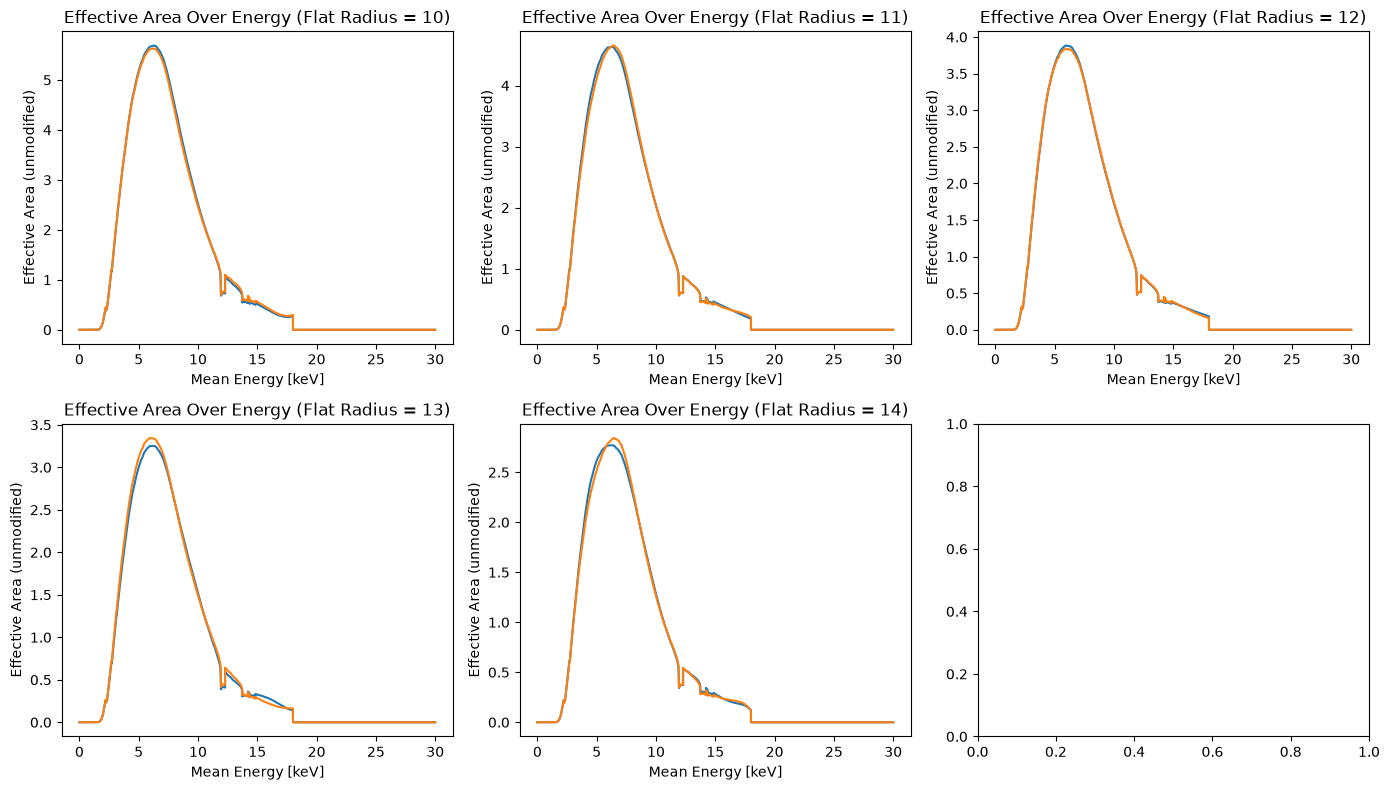

In [14]:
fig1, ax1 = relevantPlots(EMean, list10, list11, list12, list13, list14)

In [15]:
def arfPlots(EMean, resultsList10, resultsList11, resultsList12, resultsList13, resultsList14):    
    #Begin actually graphing
    fig, ax = plt.subplots(1, 2,figsize=(14, 8))
    
    ax[0].plot(EMean, resultsList10[0], label="Flat Radius = 10")  
    ax[0].plot(EMean, resultsList11[0], label="Flat Radius = 11") 
    ax[0].plot(EMean, resultsList12[0], label="Flat Radius = 12") 
    ax[0].plot(EMean, resultsList13[0], label="Flat Radius = 13") 
    ax[0].plot(EMean, resultsList14[0], label="Flat Radius = 14") 
    ax[0].set_title("Effective Area Over Energy (No Scaling)")
    ax[0].set_xlabel("Mean Energy [keV]")
    ax[0].set_ylabel("Effective Area")
    ax[0].legend()

    arcsec2_to_sr = 2.350443e-11
    deltaOmega = ((3.1*60)**2 * 34/36 *arcsec2_to_sr)
    
    ax[1].plot(EMean, [val*100*np.pi for val in resultsList10[0]], label="Flat Radius = 10")  
    ax[1].plot(EMean, [(val*121*np.pi) for val in resultsList11[0]], label="Flat Radius = 11") 
    ax[1].plot(EMean, [(val*144*np.pi) for val in resultsList12[0]], label="Flat Radius = 12") 
    ax[1].plot(EMean, [(val*169*np.pi) for val in resultsList13[0]], label="Flat Radius = 13") 
    ax[1].plot(EMean, [(val*196*np.pi) for val in resultsList14[0]], label="Flat Radius = 14") 
    ax[1].set_title("Effective Area Over Energy (Scaled by pi*flatRadius**2)")
    ax[1].set_xlabel("Mean Energy [keV]")
    ax[1].set_ylabel("Effective Area")
    ax[1].legend()
    

    plt.tight_layout()
    plt.show()

    return fig, ax

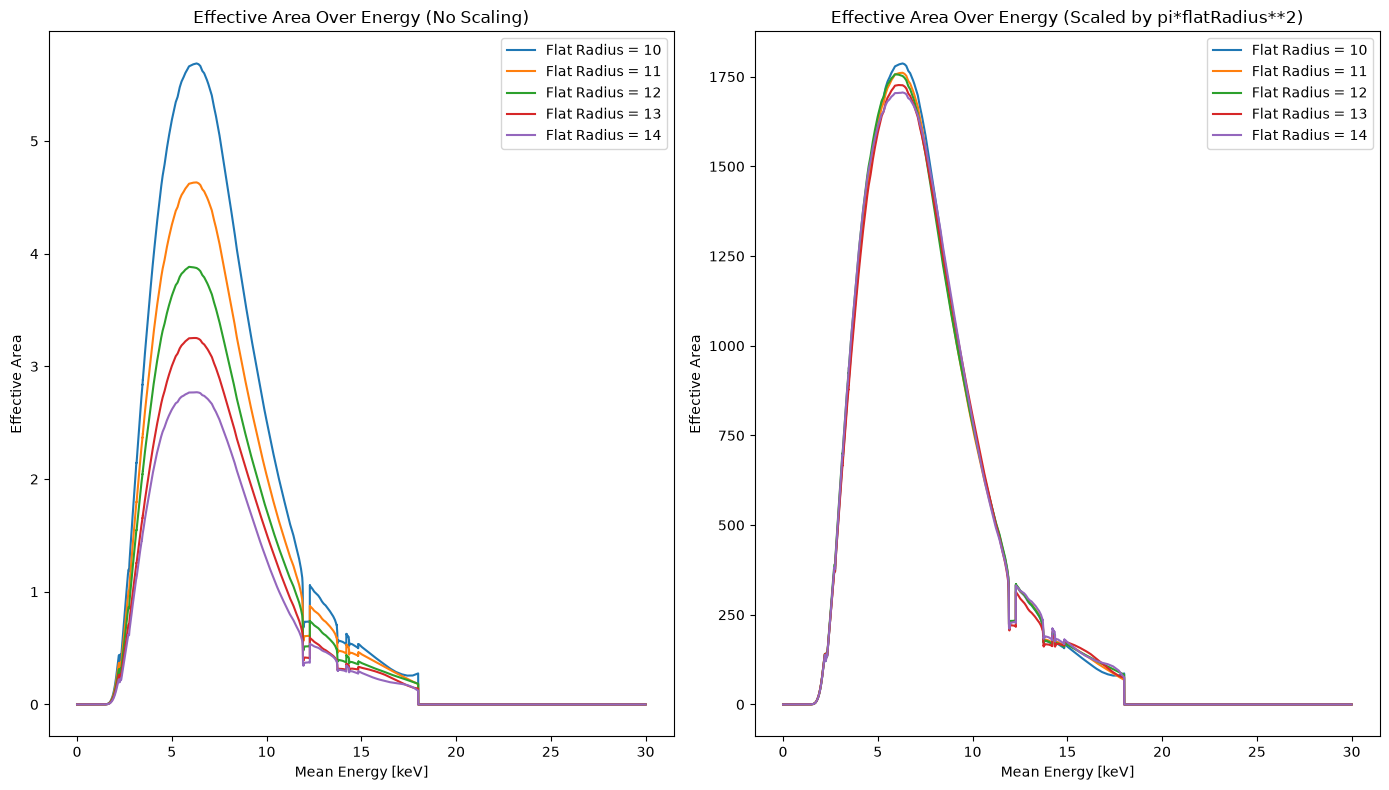

In [17]:
fig2, ax2 = arfPlots(EMean, list10, list11, list12, list13, list14)

# Calibrating Using the Iron Line

### A Dataset that has a solid amount of Points

In [14]:
Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux, cout_max, cout_min, effA, l, b = loadFile('ironDirectory/300003010')

In [1]:
backgroundParams, signalParams, profileSignal, bestFitTestStat, bestFit, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, 6.49, 0.025)
print(f"Best fit signal amplitude: {profileSignal[0]} \nBest fit background logA: {profileSignal[1]} \nBest fit background power law slope: {profileSignal[2]} \nBest Fit Test Statistic: {bestFitTestStat}")

In [2]:
fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, profileSignal, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, 6.49, Exp)

# Searching the Data for Lines

The ultimate goal here is to look through the data and find a line signature without having to know it going in. To test our ability to do this, let's search for lines in this data.

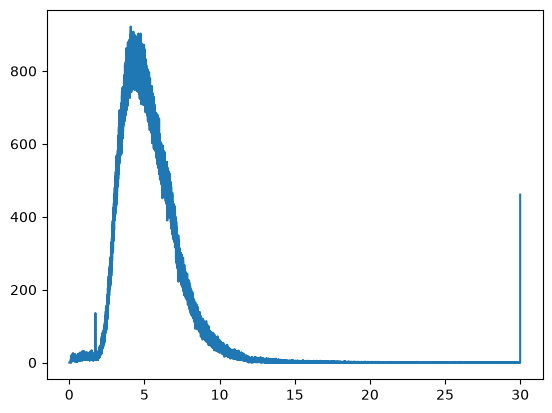

In [10]:
#Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux, cout_max, cout_min, effA, l, b = loadFile('oldFileStorage3/300002020')
Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux, cout_max, cout_min = loadFile('fileStorage3/300002020')


E_in  = EMean
dE_in = dE

arcsec2_to_sr = 2.350443e-11
roi_size = np.pi * (10 * 60)**2 * arcsec2_to_sr

R = Det_res * roi_size # (n_out, n_in), [cm^2 sr] # response matrix; roi_size is the flatcircle area in steradians, and det_res already contains the effA from arf

plt.plot(EMean, Counts)

In [ ]:
plt.plot(EMean[:-1], Counts[:-1])
print(l, b)

In [ ]:
arcsec2_to_sr = 2.350443e-11
deltaOmega = ((3.1*60)**2 * 34/36 *arcsec2_to_sr)


plt.plot(EMean, effA/deltaOmega)
plt.title("Effective Area by Energy for 300002020")
plt.xlabel("Energy (keV)")
plt.ylabel("Effective area (cm$^2$)")
plt.show()

### Quick Detour to plot the Effective Area

In [11]:
#To do this, we need to monkey around a bit with the .arf file. Let's start by loading up the data
from astropy.io import fits

with fits.open("300002020/radius{1}Iteration{1}.arf") as hdul:
    print(hdul.info())
    data = hdul[1].data
    print(data.columns)

Filename: 300002020/radius{3}Iteration{3}.arf
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   ()      
  1  SPECRESP      1 BinTableHDU     81   60000R x 3C   [E, E, E]   
None
ColDefs(
    name = 'ENERG_LO'; format = 'E'; unit = 'keV'
    name = 'ENERG_HI'; format = 'E'; unit = 'keV'
    name = 'SPECRESP'; format = 'E'; unit = 'cm^2'
)


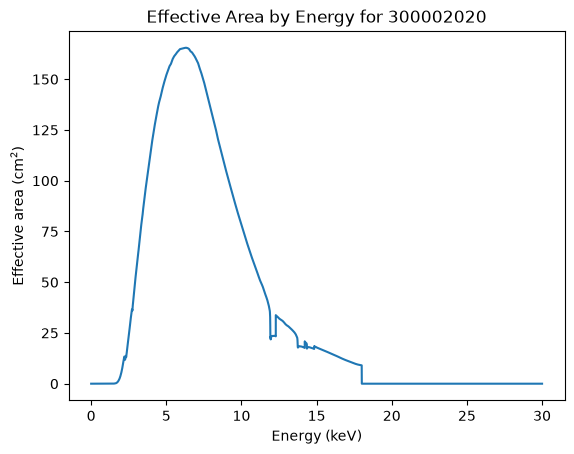

In [12]:
elo = data["ENERG_LO"]
ehi = data["ENERG_HI"]
area = np.array(data["SPECRESP"])


energy = 0.5 * (elo + ehi)

arcsec2_to_sr = 2.350443e-11
roiFactor = np.pi * (10 * 60)**2 * arcsec2_to_sr 

plt.plot(energy, area)
#plt.plot(energy, effA/deltaOmega)
plt.title("Effective Area by Energy for 300002020")
plt.xlabel("Energy (keV)")
plt.ylabel("Effective area (cm$^2$)")
plt.show()

### On With the Show!

[417.06493716 415.7928239  414.53942393 413.30474006 412.08877461
 410.89152947 409.71300607 408.55320537 407.41212789 406.28977367
 405.18614233 404.10123301 403.03504438 401.98757469 400.95882171
 399.94878275 398.95745468 397.98483391 397.0309164  396.09569763
 395.17917267 394.28133611 393.40218209 392.54170431 391.69989601
 390.87674999 390.0722586  389.28641375 388.51920688 387.77062902
 387.04067075 386.3293222  385.63657306 384.96241259 384.30682961
 383.66981253 383.05134929 382.45142743 381.87003404 381.30715581
 380.76277899 380.2368894  379.72947247 379.24051318 378.76999613
 378.31790547 377.88422498 377.468938   377.0720275  376.69347601
 376.33326568 375.99137828 375.66779516 375.3624973  375.07546527
 374.80667928 374.55611915 374.32376431 374.10959383 373.91358641
 373.73572037 373.57597367 373.4343239  373.31074831 373.20522377
 373.11772682 373.04823364 372.99672006 372.96316158 372.94753336
 372.94981022 372.96996665 373.00797681 373.06381454 373.13745337
 373.22886

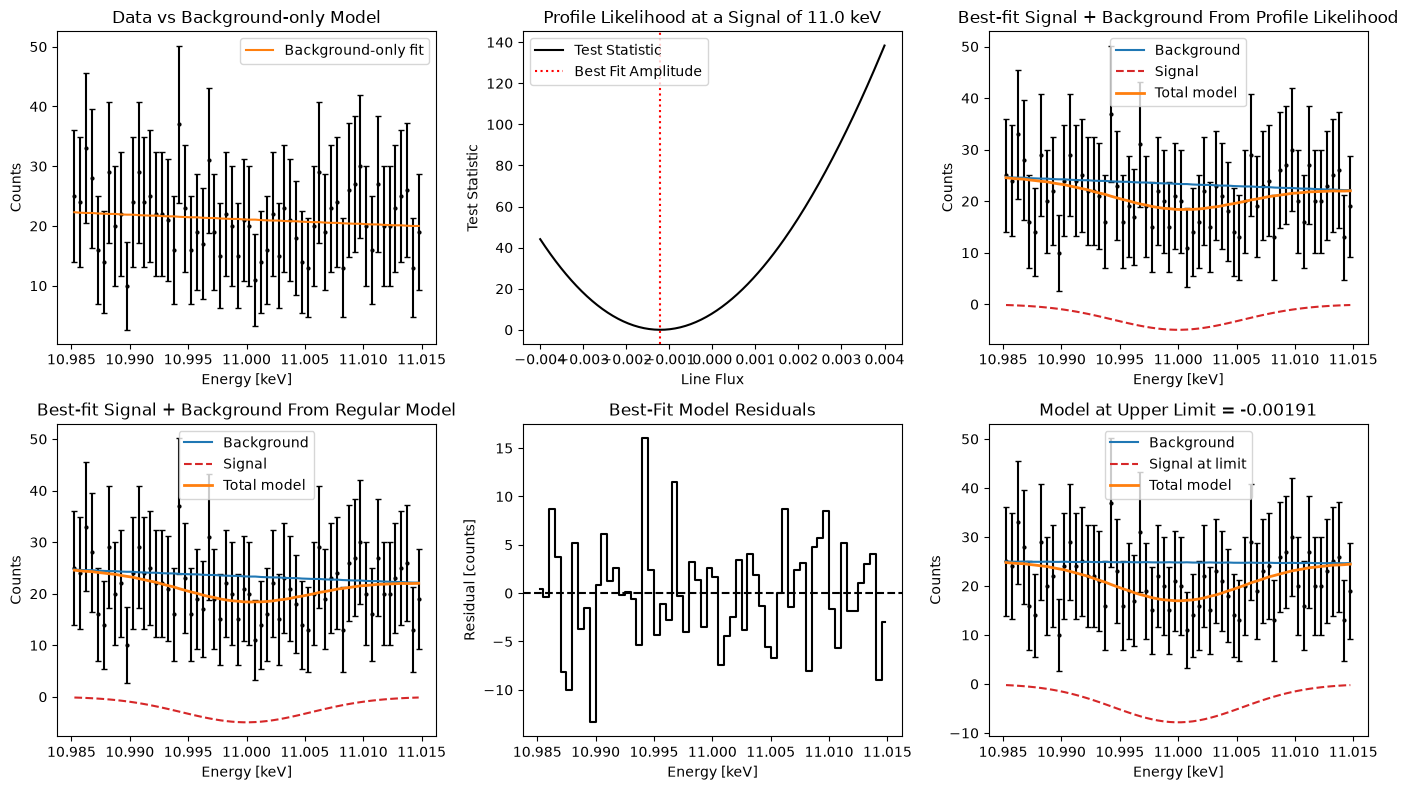

In [14]:
lineVal = 11.0
backgroundParams, signalParams, profileSignal, bestFitTestStat, bestFit, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, lineVal, 0.015)
print(f"Best fit signal amplitude: {profileSignal[0]} \nBest fit back|ground logA: {profileSignal[1]} \nBest fit background power law slope: {profileSignal[2]} \nBest Fit Test Statistic: {bestFitTestStat}")
fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, profileSignal, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, lineVal, Exp)

[np.float64(11.032923840330394), np.float64(10.831544270958972), np.float64(12.517868446295704), np.float64(11.614156909940636), np.float64(9.040866593420052), np.float64(8.526881074512286), np.float64(11.800951207126328), np.float64(9.98096721172558), np.float64(10.415868799558396), np.float64(7.375644200371034), np.float64(10.831544270958972), np.float64(11.800951207126328), np.float64(10.831544270958972), np.float64(11.032923840330394), np.float64(10.415868799558396), np.float64(10.415868799558396), np.float64(10.200988970505897), np.float64(9.040866593420052), np.float64(13.192697743082086), np.float64(10.625951316762002), np.float64(9.040866593420052), np.float64(9.755415536136761), np.float64(9.285903289225551), np.float64(12.165166564590457), np.float64(9.755415536136761), np.float64(8.788118531295673), np.float64(10.415868799558396), np.float64(9.98096721172558), np.float64(8.788118531295673), np.float64(10.200988970505897), np.float64(9.98096721172558), np.float64(7.6820999241

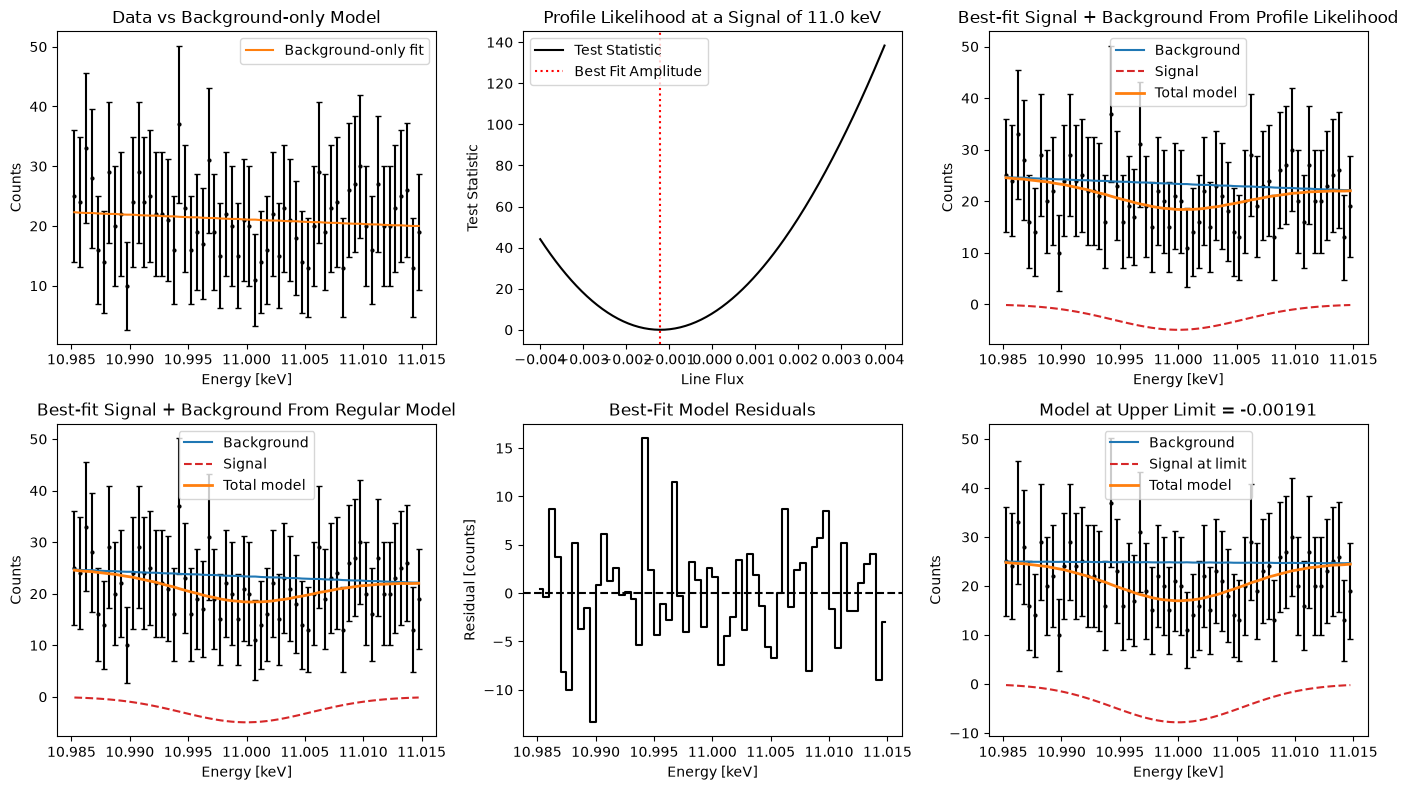

In [13]:
#Bonus cell in case we want to tweak the graphs without re-running the entire sim

fig, axes = relevantPlots(EMean, Counts, backgroundParams, signalParams, profileSignal, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals, lineVal, Exp)

In [ ]:
lineVals = []

baseVal = 0.01
for x in range(400):
    lineVals.append(baseVal + 0.05 * x)

testStats = []

for lineVal in lineVals:
    print("Run number", int((lineVal - baseVal)/0.05 + 0.1))
    backgroundParams, signalParams, profileSignal, bestFitTestStat, bestFit, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, lineVal, 0.025)    
    testStats.append(bestFitTestStat)

print(testStats)
plt.plot(lineVals, testStats)

In [ ]:
plt.plot(lineVals, testStats)

### Scanning Iron Line Data for the Iron Line

In [ ]:
Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, Flux, cout_max, cout_min = loadFile('ironDirectory/300003010/outputFile.h5')
plt.plot(EMean, Counts)

In [ ]:
lineVals = []

baseVal = 0.01
for x in range(400):
    lineVals.append(baseVal + 0.05 * x)

testStats = []

for lineVal in lineVals:
    print("Run number", int((lineVal - baseVal)/0.05 + 0.1))
    backgroundParams, signalParams, profileSignal, bestFitTestStat, bestFit, bfList, A_sig_array, testStat, limit_signal_strength, reducedVals = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, lineVal, 0.025)    
    testStats.append(bestFitTestStat)

print(testStats)
plt.plot(lineVals, testStats)

In [ ]:
lineVals = []

baseVal = 5.49
for x in range(40):
    lineVals.append(baseVal + 0.05 * x)

testStats = []

for lineVal in lineVals:
    print("Run number", int((lineVal - baseVal)/0.05 + 0.1))
    backgroundParamsI, signalParamsI, profileSignalI, bestFitTestStatI, bestFitI, bfListI, A_sig_arrayI, testStatI, limit_signal_strengthI, reducedValsI = runPipeline(Counts, Det_res, Exp, Cin_min, Cin_max, EMean, dE, lineVal, 0.025)    
    testStats.append(bestFitTestStat)

print(testStats)
plt.plot(lineVals, testStats)